In [19]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [20]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.07749498 0.03747346 0.23848796 ... 0.06018617 0.02315114 0.05157632]
 [0.16756208 0.08102628 0.51566613 ... 0.13013641 0.05005812 0.11151993]
 [0.2839255  0.13729495 0.87377029 ... 0.2205096  0.08482097 0.18896491]
 ...
 [0.28164481 0.1361921  0.86675154 ... 0.21873831 0.08413963 0.18744701]
 [0.09128615 0.04414231 0.28092978 ... 0.07089702 0.02727117 0.06075495]
 [0.07967593 0.03852807 0.24519973 ... 0.06187999 0.02380268 0.05302783]]

Noisy Matrix (with Homoscedastic Noise):
[[ 0.00847159 -0.13244498  0.24812178 ...  0.02288708  0.09898417
   0.13081507]
 [ 0.08418038  0.08526703  0.41054567 ...  0.22141381  0.00375435
   0.08983943]
 [ 0.25884582  0.21367296  0.81921598 ...  0.39063021  0.19675105
   0.36851646]
 ...
 [ 0.23410619  0.09963953  0.86086865 ...  0.17640448 -0.10928086
   0.01968723]
 [ 0.11752737  0.21304998  0.43408951 ...  0.00529183 -0.17377271
   0.02813284]
 [ 0.13860261  0.10366446  0.23117289 ...  0.14797515  0.05241133
   0.11

In [21]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [22]:
mycebmf=  cEBMF(data= noisy_matrix) 

mycebmf.initialise_factors()

In [23]:
 
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([-0.0505,  0.0891,  0.0270, -0.1182,  0.2493, -0.0805,  0.3406, -0.1571,
        -0.0380, -0.2083, -0.0030, -0.1565,  0.4479,  0.1340, -0.1948, -0.2581,
         0.3835,  0.0363,  0.1281, -0.1545, -0.1583,  0.0079,  0.2010,  0.3231,
        -0.4106,  0.0099,  0.2467,  0.2231,  0.1143,  0.0373, -0.1834, -0.0333,
        -0.2130,  0.1976,  0.1922,  0.1709,  0.3120, -0.0948,  0.2738,  0.0406,
        -0.1466, -0.2658, -0.1741,  0.0488,  0.2485,  0.1373, -0.2180,  0.0698,
        -0.1616,  0.1272], dtype=torch.float64)
tensor([ 7.5487e-02, -6.0997e-02, -2.9751e-01, -1.5539e-01,  2.0333e-01,
        -1.3492e-01, -1.6845e-01, -2.8834e-02, -8.4956e-02,  1.0141e-05,
        -9.1993e-02, -5.7315e-02,  9.7982e-02, -1.6783e-02, -9.1167e-02,
        -2.4826e-01,  1.8133e-01, -1.3297e-01,  2.3577e-02,  3.6854e-02,
         1.7890e-01, -8.2879e-02,  2.0352e-01, -3.1052e-01, -1.8836e-01,
         2.1508e-01,  2.3218e-01,  1.1862e-01,  3.7874e-02,  1.8366e-01,
        -1.2611e-01, -5.1330e-02, 

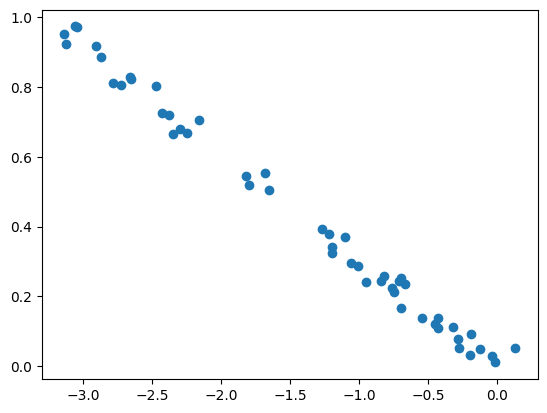

In [24]:
plt.scatter( mycebmf.L[:,0],u)

In [25]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.0697, 0.0351, 0.2024,  ..., 0.0495, 0.0258, 0.0361],
        [0.1914, 0.0907, 0.5143,  ..., 0.1473, 0.0390, 0.0961],
        [0.3295, 0.1460, 0.9033,  ..., 0.2597, 0.0698, 0.1755],
        ...,
        [0.3024, 0.1455, 0.8119,  ..., 0.2395, 0.0809, 0.1424],
        [0.1099, 0.0588, 0.3354,  ..., 0.0448, 0.0504, 0.0576],
        [0.0883, 0.0391, 0.2219,  ..., 0.0799, 0.0044, 0.0447]],
       dtype=torch.float64)

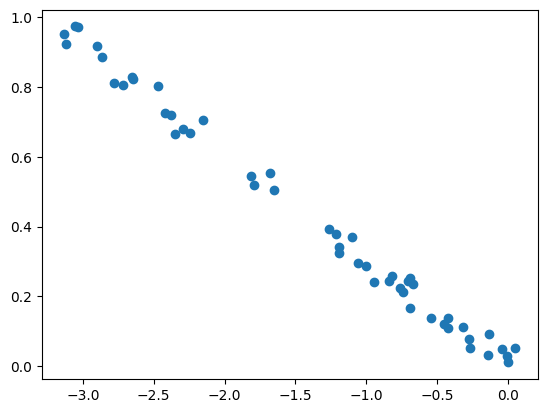

In [26]:
plt.scatter( mycebmf.L[:,0],u)

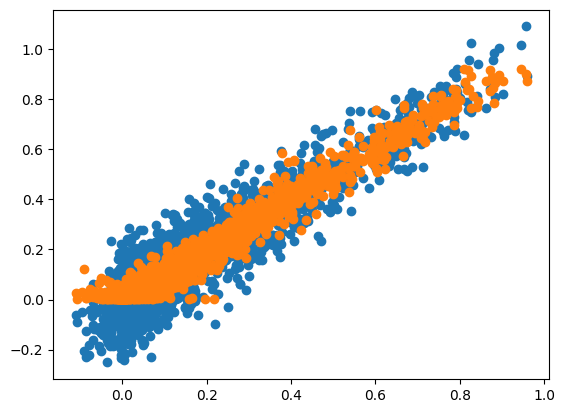

In [27]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [28]:
mycebmf=  cEBMF(data= noisy_matrix) 
mycebmf.initialise_factors()

In [29]:
mycebmf.fit()

CEBMFResult(L=tensor([[-6.9872e-01, -7.1662e-05],
        [-1.8259e+00,  1.4529e-04],
        [-3.1407e+00, -2.3680e-04],
        [-9.4988e-01, -6.9708e-05],
        [-1.0092e+00,  4.9582e-04],
        [-1.8047e+00, -5.4733e-06],
        [-4.2606e-01, -1.0505e-04],
        [-2.6718e+00, -3.9168e-04],
        [-2.4827e+00,  1.8049e-05],
        [-2.7966e+00,  4.5801e-04],
        [-8.4287e-01,  2.0093e-04],
        [-6.7341e-01,  7.8940e-03],
        [-1.1021e-01,  5.3219e-04],
        [ 3.7052e-03, -3.1720e-01],
        [-7.6417e-01,  2.1800e-05],
        [-3.0751e+00, -8.7694e-04],
        [-6.9622e-01, -1.8067e-05],
        [-2.7375e+00,  9.8740e-04],
        [-1.6628e+00,  1.2497e-05],
        [-1.2730e+00, -1.5693e-04],
        [-3.1510e+00,  4.8538e-05],
        [-5.4628e-01, -6.9966e-06],
        [-4.5361e-01,  4.3446e-05],
        [-2.5285e-01,  2.1208e-04],
        [-2.1667e+00,  4.0556e-04],
        [-9.8339e-02,  2.3778e-04],
        [-3.0559e+00, -6.2070e-04],
        [-3.07

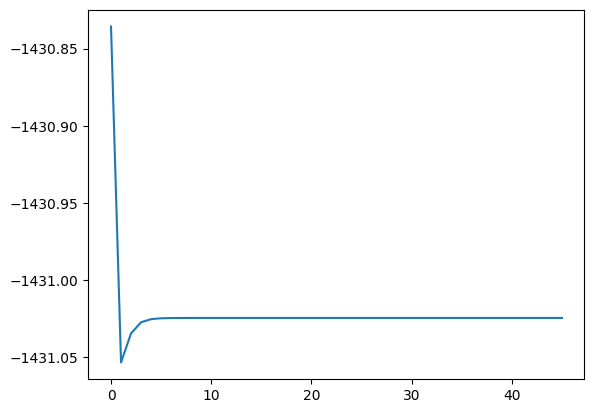

In [30]:
plt.plot(mycebmf.obj)

tensor(0.0033, dtype=torch.float64)

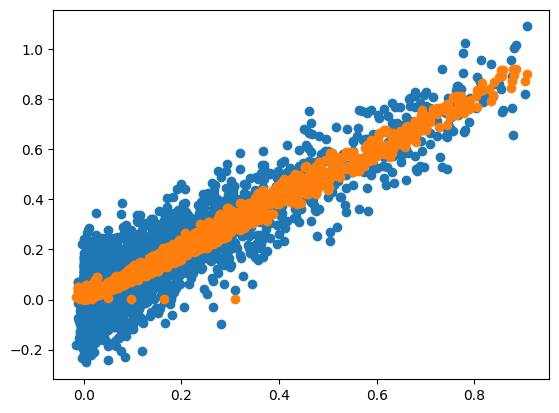

In [31]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [32]:
results =[]
tau_est =[] 
    # Parameters
n, p = 50, 40
noise_std = 0.1

for i in range(100):
    torch.manual_seed(i)              # so you can match flashier seeds 1..100

    u = torch.rand(n, dtype=torch.float64, device=device)
    v = torch.rand(p, dtype=torch.float64, device=device)
    rank_1 = torch.outer(u, v)
    Y      = rank_1 + noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    m = cEBMF(data=Y, K=1)             # prior_L = prior_F = "norm" by default
    m.initialise_factors()              # SVD init
    m.fit(50)
    m._update_fitted_value()

    rmse = torch.sqrt(torch.mean((m.Y_fit - rank_1) ** 2)).item()
    var_hat = (1.0 / m.tau).item()
    results.append(rmse)
    tau_est.append(var_hat)

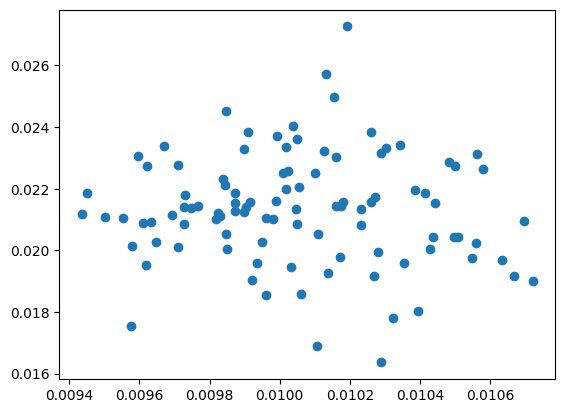

In [33]:
plt.scatter( tau_est, results)

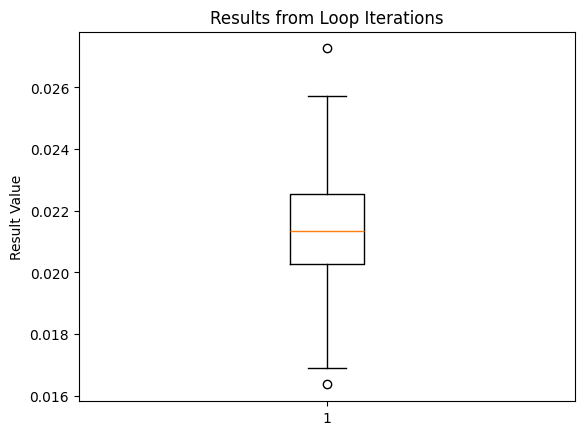

In [34]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [39]:
np.quantile(results,q=0.5)

np.float64(0.02133678878980924)

In [40]:
res= np.asarray(results)
np.mean(res )

np.float64(0.021335144254991736)

In [37]:
np.sqrt(np.var(res ))

np.float64(0.001800007536041549)

In [38]:
# 0.002615278465597284